# ══════════════════════════════════════════════════════════════════════
# Single-Dataset Experiments — Dual-Branch Fusion Variants on Derm7pt or MILK10k

Seven architectural variants, four thematic sections, **one configurable dataset**. Pick `derm7pt` or `milk10k` via the `ACTIVE_DATASET` switch in §1 and the whole pipeline runs once against that choice — 7 trainings per run, not 14.

### Dataset configuration

Set `ACTIVE_DATASET` in §1 setup to either `'derm7pt'` or `'milk10k'`. The full pipeline runs on that dataset only. To compare datasets, run the notebook twice with different `ACTIVE_DATASET` values; checkpoints are dataset-suffixed so they won't clash.

## Model specifications

| Tag | Architecture | Used in | Checkpoint stem |
|---|---|---|---|
| `single_rgb` | ResNet50 → AvgPool → FC (clinical image only) | §2 Fundamentals | `thesis_singlebranch_rgb` |
| `baseline_concat` | Dual ResNet50 → Concat(4096) → Conv1×1(1024) → BN+ReLU → AvgPool → FC | §2 Fundamentals | `thesis_baseline_concat` |
| `se_concat` | Dual SE-ResNet50 (channel attention) → Concat → Conv1×1 → FC | §3 Attention · §5 (Without Cross-Attn) | `thesis_se_concat` |
| `add_fusion` | Dual ResNet50 → element-wise + → BN+ReLU → FC | §4 Feature Fusion | `thesis_addfusion` |
| `mul_fusion` | Dual ResNet50 → element-wise × → BN+ReLU → FC | §4 Feature Fusion | `thesis_mulfusion` |
| `crossattn` | Dual ResNet50 → Bidirectional Cross-Attention → FC | §4 Feature Fusion · §5 (Without SE) | `thesis_crossattn` |
| `full_se_crossattn` | Dual SE-ResNet50 → Bidirectional Cross-Attention → FC | §5 Full Model | `thesis_full_se_crossattn` |

## Section layout

1. **Setup** — data, loaders, training helpers, **dataset selector**
2. **Fundamentals** — single-branch RGB vs dual-branch concat baseline
3. **Attention** — SENet channel attention with concat fusion
4. **Feature Fusion** — element-wise addition, element-wise multiplication, bidirectional cross-attention
5. **Ablation Study** — Full Model (SE + Cross-Attn) vs Without Channel Attention vs Without Cross-Attention
6. **Grand Comparison** — all 7 variants on the active dataset, single table + bar chart

Per run: **7 fresh trainings** (5 unique + 2 reused by ablation). Ablation reuses §3 (`se_concat`) and §4.3 (`crossattn`) checkpoints — no retraining for the two negative ablations.

*RGB = clinical close-up photo · dermoscopic image — the two modalities paired per lesion.*

## 1 — Setup: imports, data, loaders

In [1]:
import os, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cuda


### Dataset selector

**Pick the dataset here.** Set `DATASET_DIR` to either `Path('dataset') / 'Derm7pt'` or `Path('dataset') / 'milk10k'`. Everything downstream — splits, loaders, training, evaluation, checkpoints — runs against this single dataset. To switch: change `DATASET_DIR`, restart kernel, run all.

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                          DATASET SELECTOR                                ║
# ║   Change this single line to switch between Derm7pt and MILK10k.         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

DATASET_DIR = Path('dataset') / 'milk10k'    # or Path('dataset') / 'milk10k'

DATASET_NAME = DATASET_DIR.name.lower()
assert DATASET_NAME in ('derm7pt', 'milk10k'), \
    f'Unrecognized DATASET_DIR: {DATASET_DIR}. Expected "Derm7pt" or "milk10k".'
print(f'>>> DATASET_DIR  = {DATASET_DIR}')
print(f'>>> DATASET_NAME = {DATASET_NAME}')


>>> DATASET_DIR  = dataset\milk10k
>>> DATASET_NAME = milk10k


In [3]:
# ── Dataset-specific dataframe assembly ──────────────────────────────────────
if DATASET_NAME == 'derm7pt':
    derm_raw = pd.read_csv(DATASET_DIR / 'meta' / 'meta.csv')
    derm_raw['clinic_path'] = derm_raw['clinic'].apply(lambda x: str(DATASET_DIR / 'images' / x))
    derm_raw['derm_path']   = derm_raw['derm'].apply(lambda x: str(DATASET_DIR / 'images' / x))
    derm_raw['diagnosis']   = derm_raw['diagnosis'].str.strip().str.lower()
    diagnosis_groups = {
        'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
        'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
        'melanoma metastasis': 'MEL',
        'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
        'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
        'recurrent nevus': 'NV',
        'basal cell carcinoma': 'BCC',
        'seborrheic keratosis': 'SK',
        'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
        'melanosis': 'MISC', 'miscellaneous': 'MISC',
    }
    derm_raw['diagnosis_group'] = derm_raw['diagnosis'].map(diagnosis_groups)
    dataset_df = derm_raw[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
else:  # milk10k
    milk_meta = pd.read_csv(DATASET_DIR / 'MILK10k_Training_Metadata.csv')
    milk_gt   = pd.read_csv(DATASET_DIR / 'MILK10k_Training_GroundTruth.csv')
    milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK',
                      'DF': 'MISC', 'VASC': 'MISC'}
    drop_classes = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
    gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
    milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
    milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
    milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
    clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
                   [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
    derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
                   [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
    paths = clinic_meta.merge(derm_meta, on='lesion_id')
    milk_raw = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
    milk_raw['clinic_path'] = milk_raw.apply(
        lambda r: str(DATASET_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
    milk_raw['derm_path'] = milk_raw.apply(
        lambda r: str(DATASET_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
    dataset_df = milk_raw[['clinic_path', 'derm_path', 'diagnosis_group']].copy()

# 5-class label space (fixed across both datasets so checkpoints remain comparable)
class_names = ['BCC', 'MEL', 'MISC', 'NV', 'SK']
label_map   = {name: i for i, name in enumerate(class_names)}
dataset_df['label'] = dataset_df['diagnosis_group'].map(label_map)
dataset_df = dataset_df.dropna(subset=['label']).reset_index(drop=True)
print(f'{DATASET_NAME}: {len(dataset_df)} samples | {len(class_names)} classes ({class_names})')


class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)


# ── Transforms ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Stratified 70/15/15 split + class weights ────────────────────────────────
def build_dataset(df_in, name):
    labels  = df_in['label'].values.astype(int)
    indices = np.arange(len(df_in))
    tr, tmp = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
    va, te  = train_test_split(tmp,     test_size=0.50, stratify=labels[tmp], random_state=SEED)
    train_labels = labels[tr]
    class_counts = np.bincount(train_labels, minlength=len(class_names))
    safe_counts  = np.where(class_counts == 0, 1, class_counts)
    sample_w     = (1.0 / safe_counts)[train_labels]
    loss_w       = torch.tensor(
        [len(train_labels) / (len(class_names) * c) if c > 0 else 0.0 for c in class_counts],
        dtype=torch.float32).to(device)
    return {
        'name': name, 'df': df_in,
        'train_idx': tr, 'val_idx': va, 'test_idx': te,
        'sample_weights': sample_w,
        'loss_weights':   loss_w,
        'class_counts':   class_counts,
    }

ACTIVE_DS = build_dataset(dataset_df, DATASET_NAME)
print(f'{ACTIVE_DS["name"]:>8s}: train={len(ACTIVE_DS["train_idx"])} '
      f'val={len(ACTIVE_DS["val_idx"])} test={len(ACTIVE_DS["test_idx"])} '
      f'| class counts (train) = {ACTIVE_DS["class_counts"].tolist()}')

# ── DataLoaders ──────────────────────────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size, ds):
    """Return (train_loader, val_loader, test_loader, test_ds) for a dataset dict."""
    train_ds = SkinLesionDualDataset(ds['df'].iloc[ds['train_idx']], train_transform)
    val_ds   = SkinLesionDualDataset(ds['df'].iloc[ds['val_idx']],   val_transform)
    test_ds  = SkinLesionDualDataset(ds['df'].iloc[ds['test_idx']],  val_transform)
    samp = WeightedRandomSampler(ds['sample_weights'], len(ds['sample_weights']), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds


milk10k: 4361 samples | 5 classes (['BCC', 'MEL', 'MISC', 'NV', 'SK'])
 milk10k: train=3052 val=654 test=655 | class counts (train) = [1765, 315, 69, 522, 381]


### Backbone, hyperparameters & training utilities

Shared across all sections: `ResNet50Backbone`, training/eval loops, early stopping. Each later section calls `run_training(model, ckpt_path, tag, train_loader, val_loader, loss_weights)` and `evaluate(model, ckpt_path, tag, test_loader)`.

In [4]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)

    def forward(self, x):
        return self.features(x)


# ── Fixed hyperparameters ────────────────────────────────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0


class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def run_training(model, ckpt_path, tag, train_loader, val_loader, loss_weights):
    """Warm-up freeze -> unfreeze layer3 at UNFREEZE_EPOCH -> cosine LR, early stopping.
    Loaders + loss_weights passed in for per-dataset training."""
    model = model.to(device)
    model._freeze_backbones()
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
    early_stop = EarlyStopping(patience=PATIENCE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    early_stop_epoch = None
    start = time.time()

    for epoch in range(FINAL_EPOCHS):
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_resnets()
            optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH)
            print(f'  Epoch {epoch+1}: unfroze layer3, lr -> {LR/4:.2e}')

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
        va_loss, va_acc = validate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        early_stop(va_loss, model)
        print(f'  Ep {epoch+1:2d}/{FINAL_EPOCHS} | '
              f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
              f'es {early_stop.counter}/{PATIENCE}')

        if early_stop.stop:
            early_stop_epoch = epoch + 1
            print(f'  -> Early stop at epoch {early_stop_epoch}. Restoring best weights.')
            early_stop.restore(model)
            break

    print(f'\n{tag}: done in {(time.time()-start)/60:.1f} min | '
          f'best val loss {early_stop.best_loss:.4f}')
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names':      class_names,
        'label_map':        label_map,
        'history':          history,
        'best_val_loss':    early_stop.best_loss,
        'early_stop_epoch': early_stop_epoch,
    }, ckpt_path)
    print(f'Saved: {ckpt_path}')
    return model, history


def evaluate(model, ckpt_path, tag, test_loader):
    """Reload the best checkpoint for `model` and report held-out test metrics."""
    model = model.to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    preds, y, probs = [], [], []
    with torch.no_grad():
        for clinic_imgs, derm_imgs, lb in test_loader:
            logits, _ = model(clinic_imgs.to(device), derm_imgs.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            y.extend(lb.numpy())
            probs.extend(p.cpu().numpy())

    y = np.array(y); preds = np.array(preds); probs = np.array(probs)
    m = {
        'accuracy':          accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_macro':          f1_score(y, preds, average='macro',    zero_division=0),
        'f1_weighted':       f1_score(y, preds, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y, preds),
        'mcc':               matthews_corrcoef(y, preds),
        'log_loss':          log_loss(y, probs, labels=list(range(len(class_names)))),
    }
    print(f'\n{tag} - test-set metrics:')
    for k, v in m.items():
        print(f'  {k:<20}: {v:.4f}')
    print('\nPer-class report:')
    print(classification_report(y, preds, target_names=class_names, zero_division=0))
    return m


print('Helpers ready. Use make_loaders(BATCH_SIZE, DERM) or make_loaders(BATCH_SIZE, MILK).')

Helpers ready. Use make_loaders(BATCH_SIZE, DERM) or make_loaders(BATCH_SIZE, MILK).


In [5]:
# ── Shared comparison helper (used by §2.3, §3.x, §4.x, §5.x, §6) ────────────
def evaluate_checkpoint_quiet(cls, kwargs, ckpt_path, test_loader):
    """Load a checkpoint, evaluate on test_loader, return metrics dict.
    Silent — for use inside aggregate comparisons. Returns None if file missing."""
    if not Path(ckpt_path).exists():
        return None
    model = cls(**kwargs).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    preds, y, probs = [], [], []
    with torch.no_grad():
        for clinic_imgs, derm_imgs, lb in test_loader:
            logits, _ = model(clinic_imgs.to(device), derm_imgs.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            y.extend(lb.numpy())
            probs.extend(p.cpu().numpy())
    y = np.array(y); preds = np.array(preds); probs = np.array(probs)
    nc = len(class_names)
    metrics = {
        'accuracy':          accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_macro':          f1_score(y, preds, average='macro',    zero_division=0),
        'f1_weighted':       f1_score(y, preds, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y, preds),
        'mcc':               matthews_corrcoef(y, preds),
        'log_loss':          log_loss(y, probs, labels=list(range(nc))),
    }
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return metrics


def render_comparison(results, ds_name, title_prefix, png_stem):
    """Render a metrics table + bar chart for a {variant_name: metrics_dict} dict."""
    if not results:
        print(f'[{ds_name}] No checkpoints found — skipping figure.')
        return None
    df_cmp = pd.DataFrame(results).T
    df_cmp = df_cmp[['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                     'cohen_kappa', 'mcc', 'log_loss']]
    df_cmp.index.name = 'Model'

    fig = plt.figure(figsize=(14, max(7, 2 + 0.6 * len(df_cmp))))
    gs = fig.add_gridspec(2, 1, height_ratios=[len(df_cmp) + 2, 6], hspace=0.30)
    fig.suptitle(f'{title_prefix} — {ds_name} (held-out test set)',
                 fontsize=14, fontweight='bold', y=0.98)

    ax_t = fig.add_subplot(gs[0]); ax_t.axis('off')
    col_labels = ['Accuracy', 'Balanced Acc', 'F1 (macro)', 'F1 (weighted)',
                  'Cohen kappa', 'MCC', 'Log loss']
    cell_text = [[f'{v:.4f}' for v in row] for row in df_cmp.values]
    table = ax_t.table(cellText=cell_text, rowLabels=df_cmp.index, colLabels=col_labels,
                       cellLoc='center', rowLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 1.7)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#34495e')
        table[0, j].set_text_props(color='white', fontweight='bold')
    for j, col in enumerate(df_cmp.columns):
        best_i = df_cmp[col].idxmin() if col == 'log_loss' else df_cmp[col].idxmax()
        r = list(df_cmp.index).index(best_i)
        table[r + 1, j].set_facecolor('#d5f5e3')
        table[r + 1, j].set_text_props(fontweight='bold')
    ax_t.set_title('Green = best per metric   ·   Log loss: lower is better',
                   fontsize=9, pad=8)

    ax_b = fig.add_subplot(gs[1])
    metrics_to_plot = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                       'cohen_kappa', 'mcc']
    df_cmp[metrics_to_plot].T.plot(kind='bar', ax=ax_b, rot=0, colormap='tab10', width=0.8)
    ax_b.set_ylabel('Score'); ax_b.set_ylim(0, 1)
    ax_b.set_title('Metric comparison (higher is better)', fontsize=11)
    ax_b.set_xticklabels(['Accuracy', 'Balanced Acc', 'F1 (macro)', 'F1 (weighted)',
                          'Cohen kappa', 'MCC'])
    ax_b.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax_b.grid(alpha=0.3, axis='y')

    out_png = f'{png_stem}_{ds_name}.png'
    plt.savefig(out_png, dpi=200, bbox_inches='tight')
    print(f'[{ds_name}] Saved -> {out_png}')
    plt.show()
    return df_cmp


def mini_compare(variants, title, png_stem):
    """Evaluate each variant on ACTIVE_DS; render one figure; return {label: metrics}."""
    ds = ACTIVE_DS
    print(f'\n--- {title} · {ds["name"]} ---')
    _, _, test_loader, _ = make_loaders(BATCH_SIZE, ds)
    ds_results = {}
    for label, cls, kwargs, stem in variants:
        ckpt_path = f'{stem}_{ds["name"]}_best.pth'
        m = evaluate_checkpoint_quiet(cls, kwargs, ckpt_path, test_loader)
        if m is None:
            print(f'  {label}: {ckpt_path} not found — skipping')
            continue
        ds_results[label] = m
        print(f'  {label:<28s}  acc={m["accuracy"]:.4f}  '
              f'f1_macro={m["f1_macro"]:.4f}  kappa={m["cohen_kappa"]:.4f}')
    render_comparison(ds_results, ds['name'], title, png_stem)
    return ds_results


print('Comparison helpers ready: mini_compare(variants, title, png_stem) — runs on ACTIVE_DS.')


Comparison helpers ready: mini_compare(variants, title, png_stem) — runs on ACTIVE_DS.


## 2 — Fundamentals

Two baselines that the rest of the chapter builds on:

- **2.1 Single-Branch RGB** — one ResNet50 on the clinical image only. Establishes how far the clinical modality alone gets us, and serves as the lower bound for every dual-branch model.
- **2.2 Dual-Branch Concat** — two ResNet50 backbones (clinical + dermoscopic) whose `2048×7×7` feature maps are concatenated along the channel dim, then projected back to 1024 by a 1×1 conv. The simplest possible way to combine two modalities; serves as the baseline for every attention/fusion variant that follows.

### 2.1 — Single-Branch RGB baseline

In [6]:
class SingleBranchRGBClassifier(nn.Module):
    """Single-branch baseline: RGB (clinical) image only.
    Keeps the (clinic, derm) forward signature for compatibility with the shared
    train/validate helpers; `derm_img` is ignored."""
    def __init__(self, num_classes=5, dropout=0.32, pretrained=True):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for p in self.resnet_clinic.parameters():
            p.requires_grad = False
        for p in self.resnet_clinic.features[7].parameters():
            p.requires_grad = True

    def unfreeze_resnets(self):
        for p in self.resnet_clinic.features[6].parameters():
            p.requires_grad = True

    def forward(self, clinic_img, derm_img=None):
        x = self.pool(self.resnet_clinic(clinic_img)).flatten(1)
        return self.classifier(x), None


# Parameter count
_m = SingleBranchRGBClassifier(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Single-branch RGB: {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Single-branch RGB: 24,560,709 total params, 16,017,413 trainable in warm-up (65.2%)


In [7]:
# ── Train + evaluate Single-branch RGB on ACTIVE_DS ──────────────────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  Single-branch RGB  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_singlebranch_rgb_{ds["name"]}_best.pth'

sb_model = SingleBranchRGBClassifier(num_classes=len(class_names), dropout=DROPOUT)
sb_model, _ = run_training(
    sb_model, ckpt_path, f'Single-branch RGB [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

sb_eval = SingleBranchRGBClassifier(num_classes=len(class_names), dropout=DROPOUT,
                                    pretrained=False)
sb_metrics = evaluate(sb_eval, ckpt_path, f'Single-branch RGB [{ds["name"]}]', test_loader)
del sb_model, sb_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  Single-branch RGB  ·  dataset = milk10k
  Ep  1/60 | train 0.7704/0.4505 | val 1.5987/0.2248 | es 0/20
  Ep  2/60 | train 0.4901/0.5783 | val 1.3667/0.2813 | es 0/20
  Ep  3/60 | train 0.3947/0.6202 | val 1.6931/0.3104 | es 1/20
  Ep  4/60 | train 0.3092/0.6687 | val 1.3401/0.3823 | es 0/20
  Ep  5/60 | train 0.2636/0.7064 | val 1.3062/0.4985 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.2602/0.7192 | val 1.4742/0.3853 | es 1/20
  Ep  7/60 | train 0.2352/0.7421 | val 1.5674/0.4343 | es 2/20
  Ep  8/60 | train 0.2201/0.7500 | val 1.5347/0.4450 | es 3/20
  Ep  9/60 | train 0.2065/0.7733 | val 1.5423/0.4771 | es 4/20
  Ep 10/60 | train 0.1804/0.7910 | val 1.5380/0.5459 | es 5/20
  Ep 11/60 | train 0.1567/0.8172 | val 1.7236/0.4924 | es 6/20
  Ep 12/60 | train 0.1410/0.8332 | val 1.6713/0.4985 | es 7/20
  Ep 13/60 | train 0.1621/0.8041 | val 1.7517/0.4908 | es 8/20
  Ep 14/60 | train 0.1421/0.8372 | val 1.6369/0.5780 | es 9/20
  Ep 15/60 | train 0.1273/0.8575 

### 2.2 — Dual-Branch Concat baseline

Two ResNet50 backbones whose `2048×7×7` outputs are stacked along the channel axis (→ `4096×7×7`), then squeezed back to `1024×7×7` by a 1×1 convolution before the classifier head. The simplest dual-modality fusion — every attention / cross-modal mechanism in §3-§5 has to beat it to justify the added complexity.

In [8]:
class DualBranchBaseline(nn.Module):
    """Concat fusion baseline: dual ResNet50 → channel-stack → 1x1 conv → FC."""
    def __init__(self, num_classes=5, dropout=0.32, pretrained=True):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = ResNet50Backbone(pretrained=pretrained)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


_m = DualBranchBaseline(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Dual-Branch Concat: {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Dual-Branch Concat: 51,740,805 total params, 34,654,213 trainable in warm-up (67.0%)


In [9]:
# ── Train + evaluate Dual-Branch Concat baseline on ACTIVE_DS ────────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  Dual-Branch Concat  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_baseline_concat_{ds["name"]}_best.pth'

bl_model = DualBranchBaseline(num_classes=len(class_names), dropout=DROPOUT)
bl_model, _ = run_training(
    bl_model, ckpt_path, f'Dual-Branch Concat [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

bl_eval = DualBranchBaseline(num_classes=len(class_names), dropout=DROPOUT,
                             pretrained=False)
baseline_metrics = evaluate(bl_eval, ckpt_path, f'Dual-Branch Concat [{ds["name"]}]',
                            test_loader)
del bl_model, bl_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  Dual-Branch Concat  ·  dataset = milk10k
  Ep  1/60 | train 0.6232/0.5115 | val 1.2569/0.2554 | es 0/20
  Ep  2/60 | train 0.4117/0.6045 | val 1.4953/0.2003 | es 1/20
  Ep  3/60 | train 0.3478/0.6576 | val 1.1855/0.3226 | es 0/20
  Ep  4/60 | train 0.2540/0.7107 | val 1.0755/0.4327 | es 0/20
  Ep  5/60 | train 0.1817/0.7815 | val 1.0684/0.5367 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.1918/0.7896 | val 1.1255/0.5795 | es 1/20
  Ep  7/60 | train 0.1660/0.8129 | val 1.1315/0.5581 | es 2/20
  Ep  8/60 | train 0.1622/0.8198 | val 1.0794/0.5214 | es 3/20
  Ep  9/60 | train 0.1429/0.8483 | val 1.4257/0.5489 | es 4/20
  Ep 10/60 | train 0.1372/0.8490 | val 1.1625/0.6284 | es 5/20
  Ep 11/60 | train 0.1366/0.8627 | val 1.3019/0.5703 | es 6/20
  Ep 12/60 | train 0.1221/0.8676 | val 1.3695/0.6453 | es 7/20
  Ep 13/60 | train 0.1188/0.8676 | val 1.3543/0.6544 | es 8/20
  Ep 14/60 | train 0.0978/0.8889 | val 1.4906/0.4709 | es 9/20
  Ep 15/60 | train 0.1041/0.8788

### 2.3 — Fundamentals mini-comparison

Single-Branch RGB vs Dual-Branch Concat on each dataset. Shows how much value the dermoscopic branch adds over clinical-only on its own.


--- §2 Fundamentals · milk10k ---
  Single-Branch RGB             acc=0.4870  f1_macro=0.4516  kappa=0.3327
  Dual-Branch Concat            acc=0.5695  f1_macro=0.5040  kappa=0.4207
[milk10k] Saved -> comparison_fundamentals_milk10k.png


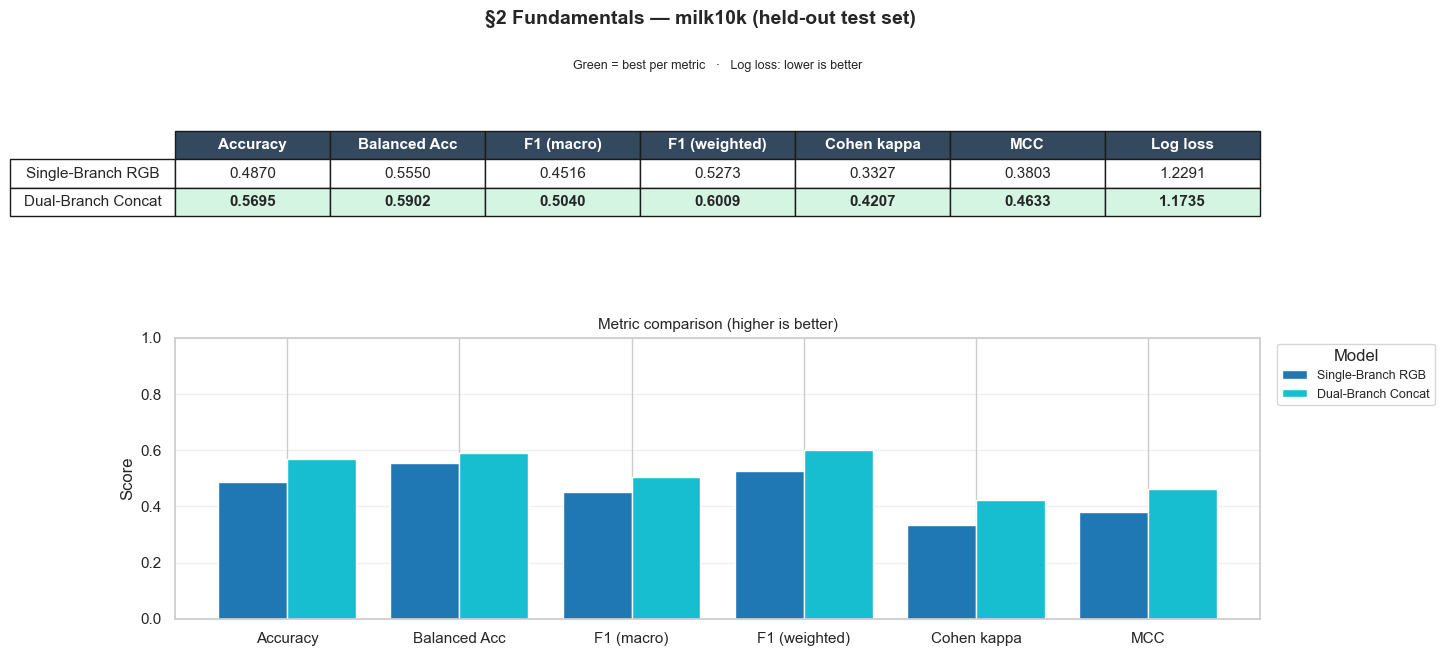

In [10]:
NC = len(class_names)
fundamentals_variants = [
    ('Single-Branch RGB',    SingleBranchRGBClassifier,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_singlebranch_rgb'),
    ('Dual-Branch Concat',   DualBranchBaseline,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_baseline_concat'),
]
fundamentals_results = mini_compare(
    fundamentals_variants, '§2 Fundamentals', 'comparison_fundamentals')

## 3 — Attention: Channel Attention (SENet)

Adds a **Squeeze-and-Excitation block** after every residual bottleneck in both ResNet50 backbones. The SE block learns a per-channel scaling factor from a global descriptor of the feature map, letting each modality emphasize its informative channels before fusion. Fusion itself stays the same as §2.2 (concat → 1×1 conv) so the only change vs. the baseline is the SE-augmented backbone.

The two SE-ResNet50 branches output the same `2048×7×7` shape as the plain ResNet50, so the rest of the pipeline is identical.

In [11]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: global pool → 2-layer MLP → sigmoid → channel-wise scale."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w


class SEBottleneck(nn.Module):
    """Wraps a torchvision ResNet bottleneck with an SE block after the last bn."""
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)

    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)


class SEResNet50Backbone(nn.Module):
    """ResNet50 with SE blocks injected into every bottleneck. Output [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)

    def forward(self, x):
        return self.features(x)


class DualBranchSEResNet(nn.Module):
    """SE-ResNet50 × 2 → concat → 1x1 conv → FC. Same head as DualBranchBaseline."""
    def __init__(self, num_classes=5, dropout=0.32, pretrained=True):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = SEResNet50Backbone(pretrained=pretrained)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


_m = DualBranchSEResNet(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'SE-ResNet (concat): {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

SE-ResNet (concat): 56,770,693 total params, 37,799,941 trainable in warm-up (66.6%)


In [12]:
# ── Train + evaluate SE-ResNet (concat fusion) on ACTIVE_DS ──────────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  SE-ResNet (concat)  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_se_concat_{ds["name"]}_best.pth'

se_model = DualBranchSEResNet(num_classes=len(class_names), dropout=DROPOUT)
se_model, _ = run_training(
    se_model, ckpt_path, f'SE-ResNet (concat) [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

se_eval = DualBranchSEResNet(num_classes=len(class_names), dropout=DROPOUT,
                             pretrained=False)
se_metrics = evaluate(se_eval, ckpt_path, f'SE-ResNet (concat) [{ds["name"]}]',
                      test_loader)
del se_model, se_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  SE-ResNet (concat)  ·  dataset = milk10k
  Ep  1/60 | train 0.7758/0.4479 | val 1.7578/0.2538 | es 0/20
  Ep  2/60 | train 0.4859/0.5642 | val 1.4930/0.3410 | es 0/20
  Ep  3/60 | train 0.3802/0.6242 | val 1.2115/0.4893 | es 0/20
  Ep  4/60 | train 0.3403/0.6481 | val 1.3312/0.3089 | es 1/20
  Ep  5/60 | train 0.3154/0.6517 | val 1.1756/0.4450 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.3228/0.6714 | val 1.2581/0.3654 | es 1/20
  Ep  7/60 | train 0.2818/0.7018 | val 1.1462/0.4480 | es 0/20
  Ep  8/60 | train 0.2543/0.7336 | val 1.3543/0.4939 | es 1/20
  Ep  9/60 | train 0.2495/0.7353 | val 1.3656/0.4021 | es 2/20
  Ep 10/60 | train 0.2519/0.7395 | val 1.1362/0.5780 | es 0/20
  Ep 11/60 | train 0.2149/0.7792 | val 1.3122/0.6284 | es 1/20
  Ep 12/60 | train 0.1952/0.7870 | val 1.2567/0.5627 | es 2/20
  Ep 13/60 | train 0.1982/0.7926 | val 1.3207/0.5336 | es 3/20
  Ep 14/60 | train 0.1730/0.8031 | val 1.3977/0.5780 | es 4/20
  Ep 15/60 | train 0.1774/0.8142

### 3.x — Attention mini-comparison

SE-ResNet (concat) vs the Dual-Branch Concat baseline from §2.2. Isolates the gain from channel attention alone.


--- §3 Attention · milk10k ---
  Dual-Branch Concat            acc=0.5695  f1_macro=0.5040  kappa=0.4207
  SE-ResNet (concat)            acc=0.6305  f1_macro=0.5153  kappa=0.4697
[milk10k] Saved -> comparison_attention_milk10k.png


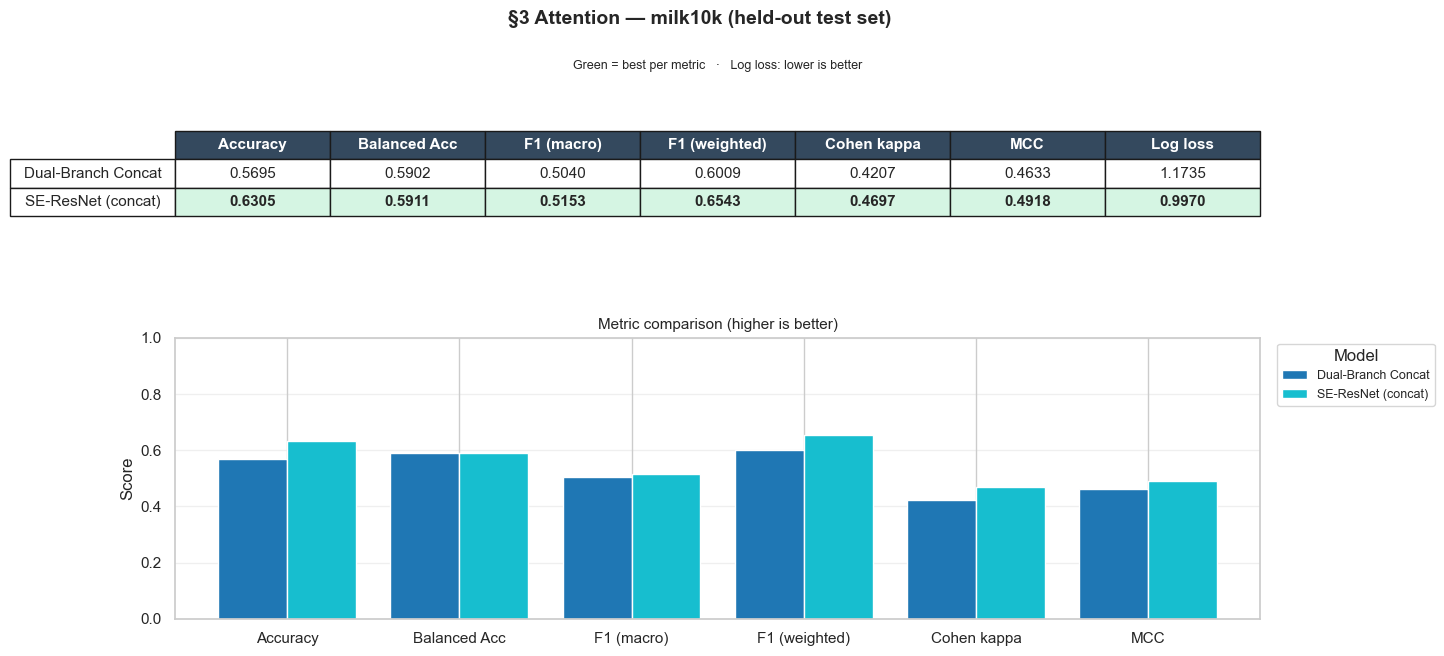

In [13]:
attention_variants = [
    ('Dual-Branch Concat',   DualBranchBaseline,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_baseline_concat'),
    ('SE-ResNet (concat)',   DualBranchSEResNet,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_se_concat'),
]
attention_results = mini_compare(
    attention_variants, '§3 Attention', 'comparison_attention')

## 4 — Feature Fusion

Three different ways to combine the two `2048×7×7` feature maps that come out of the dual ResNet50 backbones, all using the **plain (non-SE) ResNet50** so the comparison isolates the fusion operator:

- **4.1 Element-wise addition** — `feat_c + feat_d`, then BN+ReLU. Cheap, symmetric, behaves like ensemble averaging.
- **4.2 Element-wise multiplication** — `feat_c × feat_d`, then BN+ReLU. Gating-style interaction: a channel only fires if both modalities agree.
- **4.3 Bidirectional cross-attention** — two cross-attention blocks (clinical-attends-to-derm and derm-attends-to-clinical), outputs concatenated and projected back. Lets each modality query the other for relevant context.

### 4.1 — Element-wise addition

Two ResNet50 branches fused by element-wise addition of their `2048×7×7` feature maps. A BatchNorm2d after the addition keeps the activation scale stable.

In [14]:
class DualBranchElementwiseFusion(nn.Module):
    """Two-branch fusion by an element-wise operator.
    `fusion='add'` -> feat_c + feat_d ; `fusion='mul'` -> feat_c * feat_d.
    A BatchNorm2d after the fusion keeps the activation scale stable
    (the product of two post-ReLU feature maps can otherwise blow up)."""
    def __init__(self, num_classes=5, dropout=0.32, fusion='add', pretrained=True):
        super().__init__()
        assert fusion in ('add', 'mul')
        self.fusion = fusion
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = ResNet50Backbone(pretrained=pretrained)
        self.post_fuse = nn.Sequential(
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused = feat_c + feat_d if self.fusion == 'add' else feat_c * feat_d
        x = self.pool(self.post_fuse(fused)).flatten(1)
        return self.classifier(x), None


# Parameter count
_m = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT, fusion='add')
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Elementwise fusion: {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Elementwise fusion: 48,072,837 total params, 30,986,245 trainable in warm-up (64.5%)


In [15]:
# ── Train + evaluate Additive fusion on ACTIVE_DS ────────────────────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  Additive fusion  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_addfusion_{ds["name"]}_best.pth'

add_model = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                        fusion='add')
add_model, _ = run_training(
    add_model, ckpt_path, f'Additive fusion [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

add_eval = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                       fusion='add', pretrained=False)
add_metrics = evaluate(add_eval, ckpt_path, f'Additive fusion [{ds["name"]}]',
                       test_loader)
del add_model, add_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  Additive fusion  ·  dataset = milk10k
  Ep  1/60 | train 0.5871/0.5423 | val 1.4192/0.2691 | es 0/20
  Ep  2/60 | train 0.3629/0.6501 | val 1.8207/0.2875 | es 1/20
  Ep  3/60 | train 0.2739/0.7146 | val 1.2490/0.4985 | es 0/20
  Ep  4/60 | train 0.2503/0.7434 | val 1.1339/0.5076 | es 0/20
  Ep  5/60 | train 0.1790/0.7808 | val 1.1208/0.5719 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.1739/0.8106 | val 1.4151/0.5352 | es 1/20
  Ep  7/60 | train 0.1545/0.8299 | val 1.2180/0.6407 | es 2/20
  Ep  8/60 | train 0.1413/0.8372 | val 1.1583/0.6560 | es 3/20
  Ep  9/60 | train 0.1344/0.8585 | val 1.0508/0.6239 | es 0/20
  Ep 10/60 | train 0.1097/0.8820 | val 0.9711/0.7339 | es 0/20
  Ep 11/60 | train 0.1005/0.8817 | val 1.2481/0.5657 | es 1/20
  Ep 12/60 | train 0.1100/0.8856 | val 1.2428/0.6544 | es 2/20
  Ep 13/60 | train 0.0959/0.8902 | val 1.2345/0.7141 | es 3/20
  Ep 14/60 | train 0.0887/0.8919 | val 1.2313/0.6896 | es 4/20
  Ep 15/60 | train 0.0823/0.9102 | 

### 4.2 — Element-wise multiplication

Same two-branch setup as §4.1, but the branches are fused by **element-wise multiplication** — a gating-style interaction. Reuses the `DualBranchElementwiseFusion` class with `fusion='mul'`.

In [16]:
# ── Train + evaluate Multiplicative fusion on ACTIVE_DS ──────────────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  Multiplicative fusion  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_mulfusion_{ds["name"]}_best.pth'

mul_model = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                        fusion='mul')
print(f'  params: {sum(p.numel() for p in mul_model.parameters()):,} '
      f'(same architecture as additive, fusion=mul)')
mul_model, _ = run_training(
    mul_model, ckpt_path, f'Multiplicative fusion [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

mul_eval = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                       fusion='mul', pretrained=False)
mul_metrics = evaluate(mul_eval, ckpt_path, f'Multiplicative fusion [{ds["name"]}]',
                       test_loader)
del mul_model, mul_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  Multiplicative fusion  ·  dataset = milk10k
  params: 48,072,837 (same architecture as additive, fusion=mul)
  Ep  1/60 | train 0.7467/0.4246 | val 1.5018/0.1957 | es 0/20
  Ep  2/60 | train 0.5199/0.5370 | val 1.6129/0.2951 | es 1/20
  Ep  3/60 | train 0.4096/0.6029 | val 1.5293/0.2783 | es 2/20
  Ep  4/60 | train 0.3533/0.6376 | val 1.5279/0.2920 | es 3/20
  Ep  5/60 | train 0.2983/0.6619 | val 1.3270/0.3563 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.2859/0.6989 | val 1.3070/0.4939 | es 0/20
  Ep  7/60 | train 0.2737/0.7159 | val 1.2748/0.4098 | es 0/20
  Ep  8/60 | train 0.2429/0.7398 | val 1.3131/0.4862 | es 1/20
  Ep  9/60 | train 0.2375/0.7369 | val 1.1364/0.5015 | es 0/20
  Ep 10/60 | train 0.2088/0.7520 | val 1.5140/0.4358 | es 1/20
  Ep 11/60 | train 0.1939/0.7995 | val 1.4174/0.5765 | es 2/20
  Ep 12/60 | train 0.2140/0.7910 | val 1.4439/0.4587 | es 3/20
  Ep 13/60 | train 0.1794/0.7936 | val 1.1897/0.5596 | es 4/20
  Ep 14/60 | train 0.1744/0

### 4.3 — Bidirectional cross-attention

Two cross-attention blocks let each modality query the other:

- **c→d**: clinical features as queries; dermoscopic features as keys/values
- **d→c**: dermoscopic features as queries; clinical features as keys/values

Each block produces a `embed_dim`-vector summary; the two are concatenated and linearly projected back to `embed_dim` before the classifier. Implemented with `nn.MultiheadAttention(num_heads=4, embed_dim=256)`.

In [17]:
class CrossAttentionFusion(nn.Module):
    """One direction of cross-attention. Q from `clinic_feat`, K/V from `derm_feat`."""
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout,
                                            batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(),
                                    nn.Dropout(dropout), nn.Linear(embed_dim * 2, embed_dim))
        self.norm2  = nn.LayerNorm(embed_dim)
        self.pool   = nn.AdaptiveAvgPool1d(1)

    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True,
                                           average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights


class BidirectionalCrossAttnFusion(nn.Module):
    """Two cross-attention blocks (c→d and d→c), concatenated and projected."""
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)


class DualBranchBiCrossAttn(nn.Module):
    """Dual ResNet50 → bidirectional cross-attention → classifier."""
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32,
                 pretrained=True):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = ResNet50Backbone(pretrained=pretrained)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


_m = DualBranchBiCrossAttn(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'BiCrossAttn: {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

BiCrossAttn: 51,382,661 total params, 34,296,069 trainable in warm-up (66.7%)


In [18]:
# ── Train + evaluate Bidirectional Cross-Attention on ACTIVE_DS ──────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  BiCrossAttn  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_crossattn_{ds["name"]}_best.pth'

ca_model = DualBranchBiCrossAttn(num_classes=len(class_names), dropout=DROPOUT)
ca_model, _ = run_training(
    ca_model, ckpt_path, f'BiCrossAttn [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

ca_eval = DualBranchBiCrossAttn(num_classes=len(class_names), dropout=DROPOUT,
                                pretrained=False)
crossattn_metrics = evaluate(ca_eval, ckpt_path, f'BiCrossAttn [{ds["name"]}]',
                             test_loader)
del ca_model, ca_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  BiCrossAttn  ·  dataset = milk10k
  Ep  1/60 | train 0.6614/0.5190 | val 1.4533/0.2080 | es 0/20
  Ep  2/60 | train 0.4322/0.5953 | val 1.4416/0.2523 | es 0/20
  Ep  3/60 | train 0.3383/0.6474 | val 1.1605/0.3287 | es 0/20
  Ep  4/60 | train 0.2683/0.7025 | val 1.1125/0.3960 | es 0/20
  Ep  5/60 | train 0.2159/0.7425 | val 1.1467/0.3853 | es 1/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.2493/0.7280 | val 1.2136/0.4618 | es 2/20
  Ep  7/60 | train 0.2056/0.7739 | val 1.2077/0.4679 | es 3/20
  Ep  8/60 | train 0.1864/0.7887 | val 1.0401/0.6269 | es 0/20
  Ep  9/60 | train 0.1974/0.7985 | val 0.9983/0.5810 | es 0/20
  Ep 10/60 | train 0.1583/0.8234 | val 1.0347/0.5657 | es 1/20
  Ep 11/60 | train 0.1418/0.8453 | val 1.1563/0.5535 | es 2/20
  Ep 12/60 | train 0.1331/0.8503 | val 1.0310/0.5841 | es 3/20
  Ep 13/60 | train 0.1432/0.8555 | val 0.9868/0.6193 | es 0/20
  Ep 14/60 | train 0.1128/0.8729 | val 1.1569/0.6911 | es 1/20
  Ep 15/60 | train 0.1186/0.8765 | val 

### 4.x — Feature Fusion mini-comparison

All three fusion operators on each dataset — isolates the effect of the fusion mechanism with the backbone held fixed at plain ResNet50.


--- §4 Feature Fusion · milk10k ---
  Add-Fusion                    acc=0.7252  f1_macro=0.6203  kappa=0.5832
  Mul-Fusion                    acc=0.6504  f1_macro=0.5752  kappa=0.5013
  BiCrossAttn                   acc=0.6122  f1_macro=0.5637  kappa=0.4564
[milk10k] Saved -> comparison_fusion_milk10k.png


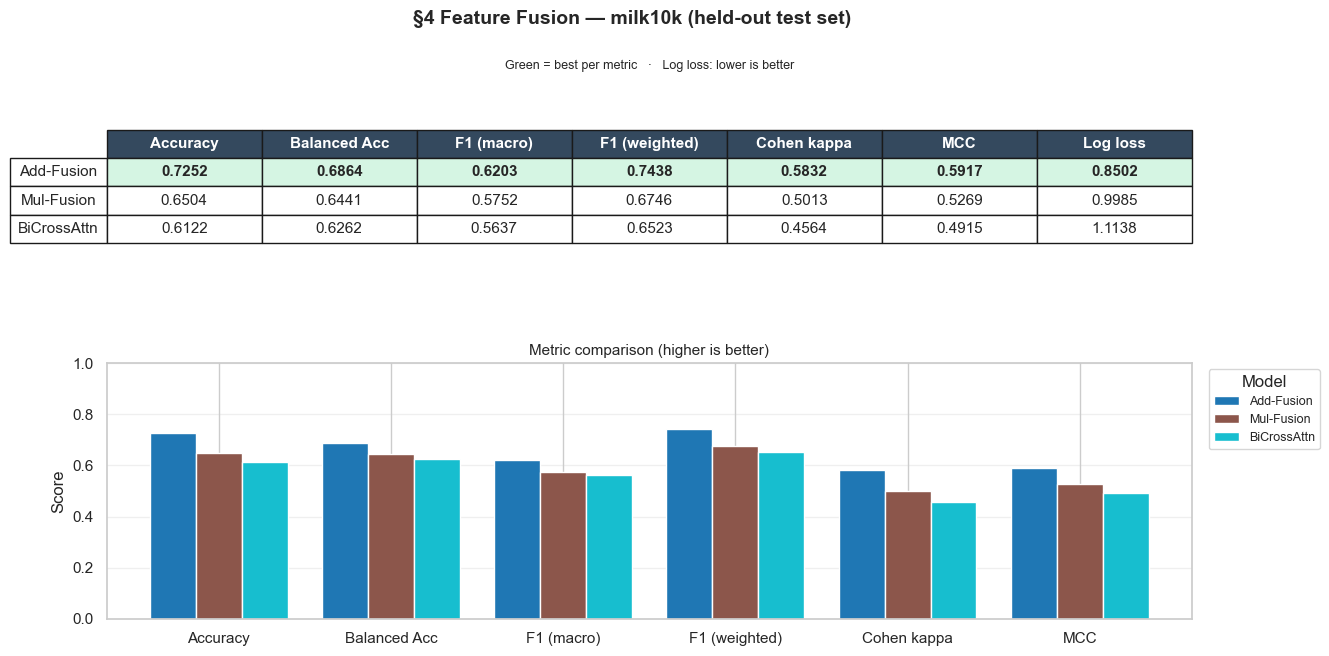

In [19]:
fusion_variants = [
    ('Add-Fusion',           DualBranchElementwiseFusion,
        {'num_classes': NC, 'dropout': DROPOUT, 'fusion': 'add', 'pretrained': False},
        'thesis_addfusion'),
    ('Mul-Fusion',           DualBranchElementwiseFusion,
        {'num_classes': NC, 'dropout': DROPOUT, 'fusion': 'mul', 'pretrained': False},
        'thesis_mulfusion'),
    ('BiCrossAttn',          DualBranchBiCrossAttn,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_crossattn'),
]
fusion_results = mini_compare(
    fusion_variants, '§4 Feature Fusion', 'comparison_fusion')

## 5 — Ablation Study

Establishes the **Full Model** (dual SE-ResNet50 + bidirectional cross-attention) and isolates each component's contribution by ablating one at a time. Three conditions, each evaluated on Derm7pt and MILK10k:

- **Full Model** — SE-ResNet50 backbones + bidirectional cross-attention fusion. *Trained fresh in this section*; checkpoint stem `thesis_full_se_crossattn`.
- **Without Channel Attention** — plain ResNet50 backbones + bidirectional cross-attention (= §4.3). *Reuses* `thesis_crossattn_{ds}_best.pth`. No retraining.
- **Without Cross-Attention** — SE-ResNet50 backbones + concat fusion (= §3). *Reuses* `thesis_se_concat_{ds}_best.pth`. No retraining.

Compared to a simple "Full vs nothing" ablation, this design tells us **which of the two components is doing the heavy lifting**: if dropping SE hurts more than dropping cross-attention, the channel-attention is more important, and vice versa.

### 5.1 — Full Model architecture

In [20]:
class DualBranchSECrossCombined(nn.Module):
    """Full Model: dual SE-ResNet50 + bidirectional cross-attention fusion + classifier."""
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32,
                 pretrained=True):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = SEResNet50Backbone(pretrained=pretrained)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


_m = DualBranchSECrossCombined(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Full Model (SE + BiCrossAttn): {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Full Model (SE + BiCrossAttn): 56,412,549 total params, 37,441,797 trainable in warm-up (66.4%)


### 5.2 — Train the Full Model on each dataset

Derm7pt first, then MILK10k. Saves `thesis_full_se_crossattn_{ds}_best.pth`.

In [21]:
# ── Train + evaluate Full Model (SE + BiCrossAttn) on ACTIVE_DS ──────────────
ds = ACTIVE_DS
print(f'\n{"="*72}\n  Full Model (SE + BiCrossAttn)  ·  dataset = {ds["name"]}\n{"="*72}')
train_loader, val_loader, test_loader, _ = make_loaders(BATCH_SIZE, ds)
ckpt_path = f'thesis_full_se_crossattn_{ds["name"]}_best.pth'

full_model = DualBranchSECrossCombined(num_classes=len(class_names), dropout=DROPOUT)
full_model, _ = run_training(
    full_model, ckpt_path, f'Full Model [{ds["name"]}]',
    train_loader, val_loader, ds['loss_weights'])

full_eval = DualBranchSECrossCombined(num_classes=len(class_names), dropout=DROPOUT,
                                      pretrained=False)
full_metrics = evaluate(full_eval, ckpt_path, f'Full Model [{ds["name"]}]',
                        test_loader)
del full_model, full_eval
if torch.cuda.is_available(): torch.cuda.empty_cache()


  Full Model (SE + BiCrossAttn)  ·  dataset = milk10k
  Ep  1/60 | train 0.8480/0.4548 | val 1.9220/0.1667 | es 0/20
  Ep  2/60 | train 0.5651/0.5295 | val 1.5024/0.2248 | es 0/20
  Ep  3/60 | train 0.4802/0.5655 | val 1.2726/0.2446 | es 0/20
  Ep  4/60 | train 0.3920/0.6147 | val 1.1894/0.2645 | es 0/20
  Ep  5/60 | train 0.3373/0.6415 | val 1.2546/0.2737 | es 1/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.3801/0.6232 | val 1.2620/0.2829 | es 2/20
  Ep  7/60 | train 0.3421/0.6422 | val 1.2801/0.3058 | es 3/20
  Ep  8/60 | train 0.3195/0.6635 | val 1.3515/0.3135 | es 4/20
  Ep  9/60 | train 0.2903/0.6710 | val 1.2512/0.3654 | es 5/20
  Ep 10/60 | train 0.2885/0.7018 | val 1.1796/0.4098 | es 0/20
  Ep 11/60 | train 0.2649/0.7146 | val 1.3215/0.3976 | es 1/20
  Ep 12/60 | train 0.2475/0.7372 | val 1.2968/0.5168 | es 2/20
  Ep 13/60 | train 0.2372/0.7464 | val 1.2543/0.4113 | es 3/20
  Ep 14/60 | train 0.2137/0.7559 | val 1.3975/0.4618 | es 4/20
  Ep 15/60 | train 0.

### 5.3 — Ablation comparison

Full Model vs Without-SE (reuses §4.3 cross-attention checkpoint) vs Without-Cross-Attention (reuses §3 SE-concat checkpoint). One mini-comparison per dataset.


--- §5 Ablation Study · milk10k ---
  Full Model (SE+CrossAttn)     acc=0.6504  f1_macro=0.5622  kappa=0.4948
  Without Channel Attention     acc=0.6122  f1_macro=0.5637  kappa=0.4564
  Without Cross-Attention       acc=0.6305  f1_macro=0.5153  kappa=0.4697
[milk10k] Saved -> comparison_ablation_milk10k.png


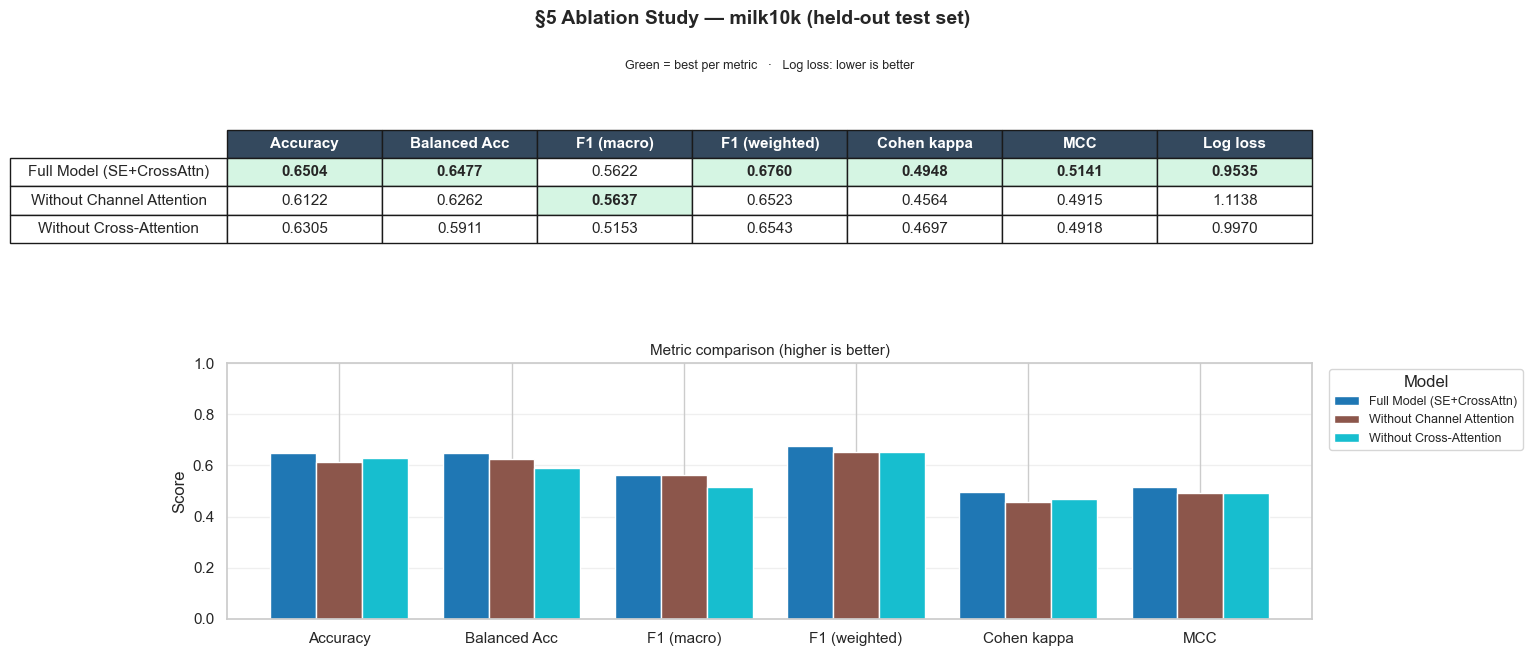

In [22]:
ablation_variants = [
    ('Full Model (SE+CrossAttn)',  DualBranchSECrossCombined,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_full_se_crossattn'),
    ('Without Channel Attention',  DualBranchBiCrossAttn,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_crossattn'),            # reused from §4.3
    ('Without Cross-Attention',    DualBranchSEResNet,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_se_concat'),            # reused from §3
]
ablation_results = mini_compare(
    ablation_variants, '§5 Ablation Study', 'comparison_ablation')

## 6 — Grand Comparison: all 7 variants on the active dataset

Loads every checkpoint produced earlier in the notebook and evaluates each on the held-out test set of the configured `ACTIVE_DATASET`. Outputs one comparison table + bar chart plus a CSV.


--- §6 Grand Comparison · milk10k ---
  Single-RGB                    acc=0.4870  f1_macro=0.4516  kappa=0.3327
  Dual-Branch Concat            acc=0.5695  f1_macro=0.5040  kappa=0.4207
  SE-ResNet (concat)            acc=0.6305  f1_macro=0.5153  kappa=0.4697
  Add-Fusion                    acc=0.7252  f1_macro=0.6203  kappa=0.5832
  Mul-Fusion                    acc=0.6504  f1_macro=0.5752  kappa=0.5013
  BiCrossAttn                   acc=0.6122  f1_macro=0.5637  kappa=0.4564
  Full Model (SE+CrossAttn)     acc=0.6504  f1_macro=0.5622  kappa=0.4948
[milk10k] Saved -> per_dataset_comparison_milk10k.png


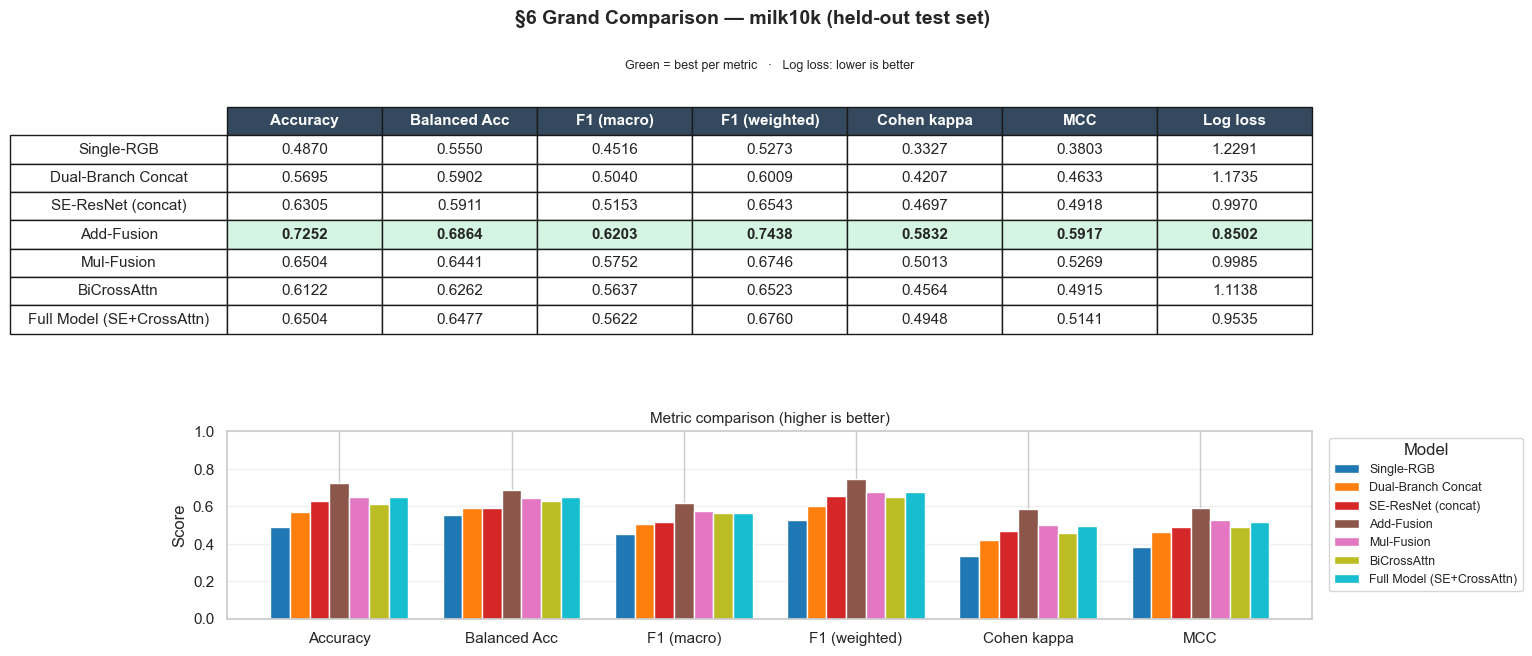


Saved -> comparison_metrics_milk10k.csv


In [23]:
# ── Grand Comparison: all 7 variants on ACTIVE_DS ────────────────────────────
GRAND_VARIANTS = [
    ('Single-RGB',                SingleBranchRGBClassifier,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_singlebranch_rgb'),
    ('Dual-Branch Concat',        DualBranchBaseline,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_baseline_concat'),
    ('SE-ResNet (concat)',        DualBranchSEResNet,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_se_concat'),
    ('Add-Fusion',                DualBranchElementwiseFusion,
        {'num_classes': NC, 'dropout': DROPOUT, 'fusion': 'add', 'pretrained': False},
        'thesis_addfusion'),
    ('Mul-Fusion',                DualBranchElementwiseFusion,
        {'num_classes': NC, 'dropout': DROPOUT, 'fusion': 'mul', 'pretrained': False},
        'thesis_mulfusion'),
    ('BiCrossAttn',               DualBranchBiCrossAttn,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_crossattn'),
    ('Full Model (SE+CrossAttn)', DualBranchSECrossCombined,
        {'num_classes': NC, 'dropout': DROPOUT, 'pretrained': False},
        'thesis_full_se_crossattn'),
]

grand_results = mini_compare(
    GRAND_VARIANTS, '§6 Grand Comparison', f'per_dataset_comparison')

# ── CSV (one row per variant for the active dataset) ─────────────────────────
if grand_results:
    df_out = pd.DataFrame(grand_results).T
    df_out = df_out[['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                     'cohen_kappa', 'mcc', 'log_loss']]
    df_out.index.name = 'Model'
    df_out.insert(0, 'dataset', ACTIVE_DS['name'])
    out_csv = f'comparison_metrics_{ACTIVE_DS["name"]}.csv'
    df_out.to_csv(out_csv)
    print(f'\nSaved -> {out_csv}')
else:
    print('No checkpoints found — train sections 2-5 first.')